In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv(r'C:\Projects_ciência_dados\project_credit_risk\data\raw\home-credit-default-risk\application_train.csv')

In [ ]:
dataset

In [ ]:
dataset.info()

In [ ]:
dataset.describe()

TARGET desbalanceado

In [ ]:
sns.countplot(data=dataset, x=dataset['TARGET'])

In [ ]:
np.unique(dataset['TARGET'], return_counts=True)

91,92% do TARGET é formado por pessoas que não tiveram inadimplência grave

In [ ]:
(282686 / 307511) * 100

Apenas 8,07% das pessoas tiveram inadimplência

Portanto, será necessário um método de balanceamento de TARGET, como o Oversampling ou Undersampling

In [ ]:
100 - ((282686 / 307511) * 100)

dataset de colunas nulas

In [ ]:
df_null = dataset.loc[:, dataset.isnull().any()]

In [ ]:
df_null

In [ ]:
df_null.isnull().sum()

As colunas que possuem mais nulos tem 214.865

In [ ]:
df_null.isnull().sum().max()

In [ ]:
df_null.loc[:, df_null.isnull().sum() == 214865]

Quase 70% dos valores são nulos

In [ ]:
(214865 / 307511) * 100

In [ ]:
d = pd.DataFrame(
    {
        'TARGET':dataset['TARGET'],
        'COMMONAREA_AVG':df_null['COMMONAREA_AVG'],
        'COMMONAREA_MODE':df_null['COMMONAREA_MODE'],
        'COMMONAREA_MEDI':df_null['COMMONAREA_MEDI']
        
    }
)

In [ ]:
d

Pouca correlação individual com o target e muitos valores nulos, devem ser excluídas

In [ ]:
sns.heatmap(d.corr(), annot=True)

Criação do dataset para armazenar colunas que serão excluídas

In [ ]:
exclusao = d.drop('TARGET', axis=1)

In [ ]:
df_null.columns

Visualizando a coluna valor da parcela do empréstimo

Poucos nulos e forte relação com o negócio

In [ ]:
df_null['AMT_ANNUITY'].isnull().sum()

In [ ]:
target = pd.DataFrame({
    'TARGET':dataset['TARGET']
})

In [ ]:
categoricas = df_null.select_dtypes(include=['object']).columns

In [ ]:
numericas  = df_null.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
categoricas

Treinamento de uma árvore de decisão com as colunas que possuem valores faltantes e o target para verificar o feature importance

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

Imputação de valores nulos com a mediana

In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

Imputação de valores categóricos com a moda e encoder

In [ ]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Aplicação dos pipelines

In [ ]:
preprocess = ColumnTransformer([
    ('num', num_pipeline, numericas),
    ('cat', cat_pipeline, categoricas)
])

In [ ]:
preprocess.set_output(transform='pandas')

In [ ]:
df_null_processed = preprocess.fit_transform(df_null)

Treinamento da árvore de decisão

In [ ]:
tree = DecisionTreeClassifier()
tree.fit(df_null_processed, target)

In [ ]:
feature_importance = pd.DataFrame({
    'coluna':df_null_processed.columns,
    'importancia':tree.feature_importances_
}).sort_values(by='importancia', ascending=False)

In [ ]:
feature_importance

Treinamento com Random Forest para verificar significância

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

Tuning de parâmetros

In [ ]:
"""parametros = {
    'min_samples_leaf':[10, 20, 50, 100],
    'min_samples_split':[10, 20, 50, 100, 200],
    'max_depth':[10, 20, 50, 100, None],
}

r = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=parametros, n_jobs=4)
r.fit(df_null_processed, target)
print(r.best_score_)
print(r.best_params_)"""

In [ ]:
random = RandomForestClassifier(n_jobs=4)
random.fit(df_null_processed, target)

Feature importance

In [ ]:
feature_importance_random = pd.DataFrame({
    'feature':df_null_processed.columns,
    'importancia':random.feature_importances_
}).sort_values(by='importancia', ascending=False)

Importâncias que são menores que a mediana

In [ ]:
feature_importance_random.loc[feature_importance_random['importancia'] < feature_importance_random['importancia'].median()]

Definição de porcentagem de nulos para cada feature

In [ ]:
def porcentagem_nulos_df(df):
    return (
        df.isnull()
          .mean()
          .mul(100)
          .reset_index()
          .rename(columns={'index': 'coluna', 0: 'porcentagem_nulos'})
          .sort_values(by='porcentagem_nulos', ascending=True)
    )


In [ ]:
pn = porcentagem_nulos_df(df_null)

In [ ]:
pn.loc[pn['porcentagem_nulos'] > 60]

In [ ]:
feature_importance['importancia'].median()

In [ ]:
feature_importance.loc[feature_importance['importancia'] < 0.004348631938518194]

Feature como DAYS_LAST_PHONE_CHANGE, CNT_FAM_MEMBERS, AMT_ANNUITY, AMT_GOODS_PRICE, EXT_SOURCE_2 devem permanecer, pois apresentam grande significância preditiva, poucos nulos e apresentam grande valor para o negócio	

COMMONAREA, NONLIVINGAPARTMENTS, LIVINGAPARTMENTS, FLOORSMIN, YEARS_BUILD, FONDKAPREMONT_MODE, HOUSETYPE_MODE Devem ser excluídas, pois apresentam baixo poder preditivo e tem mais de 60% de valores nulos

In [ ]:
dataset.shape

Respondendo perguntas de negócio

In [ ]:
numericas_dataset = dataset.select_dtypes(include=['int', 'float'])

In [ ]:
numericas_dataset.shape

In [ ]:
correlacao = numericas_dataset.corr(method='spearman')

Transformando em pares

In [ ]:
corr_pares = correlacao.unstack()

Removendo auto-correlação

In [ ]:
corr_pairs = corr_pares[corr_pares.index.get_level_values(0) !=
                        corr_pares.index.get_level_values(1)]


Correlações maiores que 0.7 e menores que 1

In [ ]:
corr_relevantes = corr_pairs[
    (corr_pairs.abs() >= 0.7) & (corr_pairs.abs() < 1.0)
].sort_values(ascending=False)


In [ ]:
corr_relevantes

Como a maioria das features que possuíram alta correlação foi de imóveis, ent irei fazer um dataset sem essas features para analisar as outras

In [ ]:
import re

def selecionar_metrica_imovel(colunas):
    grupos = {}

    for col in colunas:
        base = re.sub(r'_(AVG|MEDI|MODE)$', '', col)
        grupos.setdefault(base, []).append(col)

    cols_manter = []

    for base, cols in grupos.items():
        if f'{base}_AVG' in cols:
            cols_manter.append(f'{base}_AVG')
        elif f'{base}_MEDI' in cols:
            cols_manter.append(f'{base}_MEDI')
        else:
            cols_manter.append(cols[0])  # fallback

    return cols_manter


# aplicar apenas nas métricas de imóvel
imovel_cols = [
    c for c in numericas_dataset.columns
    if re.search(r'_(AVG|MEDI|MODE)$', c)
]

cols_manter = selecionar_metrica_imovel(imovel_cols)

# colunas finais
cols_finais = [
    c for c in numericas_dataset.columns
    if c not in imovel_cols or c in cols_manter
]

numericas_dataset_sem_imovel = numericas_dataset[cols_finais]


In [ ]:
numericas_dataset_sem_imovel

In [ ]:
correlacao_sem_imovel = numericas_dataset_sem_imovel.corr(method='spearman')

In [ ]:
corr_pares = correlacao_sem_imovel.unstack()

In [ ]:
corr_pairs = corr_pares[corr_pares.index.get_level_values(0) !=
                        corr_pares.index.get_level_values(1)]


In [ ]:
corr_relevantes = corr_pairs[
    (corr_pairs.abs() >= 0.6) & (corr_pairs.abs() < 1.0)
].sort_values(ascending=False)


In [ ]:
corr_relevantes.tail(40)

OBS_30_CNT_SOCIAL_CIRCLE     OBS_60_CNT_SOCIAL_CIRCLE -> Essas duas features possuem correlação muito forte e querem dizer quase a mesma coisa. Para reduzir a multicolinearidade, irei remover a OBS_60_CNT_SOCIAL_CIRCLE, pois traz dados mais antigos

LIVINGAREA, APARTMENS, TOTALAREA, ELEVATORS são métricas redundantes e com uma correlção muito grande, ou seja, quanto maior a área de morada, maior será a quantidade de apartamentos e área total, portanto devo permanecer com LIVINGAREA, pois é uma métrica mais geral e preditiva

REGION_RATING_CLIENT REGION_RATING_CLIENT_W_CITY Sobre essas duas features, irei manter apenas a REGION_RATING_CLIENT_W_CITY, pois atribui um valor a cidade que o cliente mora considerando infraestrutura, renda, histórico de inadimplência, região e etc, enquanto o outro considera apenas a região, portanto o de cidade é mais específico e preditivo

DEF_60_CNT_SOCIAL_CIRCLE    DEF_30_CNT_SOCIAL_CIRCLE -> Irei excluir pelo mesmo motivo do OBS_60_CNT_SOCIAL_CIRCLE

DAYS_BIRTH               EXT_SOURCE_1 ->              -0.600176 Apresentam essa correlação, pois o DAYS_BIRTH está normalizado (negativo), ent quanto mais negativo maior a idade, isso significa que quanto mais velha mais a pessoa apresenta um bom score externo. Muito disso pq alguém com mais idade apresenta um histórico maior, normalmente salário maior etc

In [ ]:
numericas_dataset.columns

Preparando o dataset para aplicar low variance

In [ ]:
x = dataset.drop('TARGET', axis=1)

In [ ]:
y = dataset['TARGET']

In [ ]:
numericas = x.select_dtypes(include=['int', 'float']).columns

In [ ]:
categoricas = x.select_dtypes(include=['object']).columns

In [ ]:
nulas_x = x.loc[:,x.isnull().any()]

In [ ]:
numericas_nulas = nulas_x.select_dtypes(include=['int', 'float']).columns

In [ ]:
categoricas_nulas = nulas_x.select_dtypes(include=['object']).columns

Aplicando imputação de nulos, encoder e normalização

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

Pipeline

In [ ]:
preprocess = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')), # Imputando nulos com a moda
        ('one_hot', OneHotEncoder(sparse_output=False)) # Aplicando encoder
    ]), categoricas), # Nas colunas categóricas
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Imputando nulos com a mediana
        ('scaler', MinMaxScaler()) # Aplicando normalização
    ]), numericas) # Nas colunas numéricas
])

Transformando a saída para pandas

In [ ]:
preprocess.set_output(transform='pandas')

Aplicando o Pipeline

In [ ]:
x_processed = preprocess.fit_transform(x)

In [ ]:
x_processed

Calculando a variância de todas as colunas (features)

In [ ]:
variancias = x_processed.var().sort_values()
variancias.head()

25% das features possuem variância menor que 0.001944, ou seja, muito baixa. Considerando uma variância máxima de 0.25, isso é apenas 0,77% da variância que poderiam atingir

In [ ]:
variancias.describe()

Low Variance

In [ ]:
from sklearn.feature_selection import VarianceThreshold

Vai eliminar todas as features que possuem variância menor que 0.002

In [ ]:
selecao = VarianceThreshold(threshold=0.002)

In [ ]:
x_low_var = selecao.fit_transform(x_processed) # Aplicando

Features que possuem variância maior que 0.002

In [ ]:
features_selecionadas = x_processed.loc[:, selecao.get_support()] 

Features que possuem variância menor que 0.002

In [ ]:
features_removidas = x_processed.loc[:, ~selecao.get_support()]

In [ ]:
features_removidas.columns

In [ ]:
variance_removidas = features_removidas.var().sort_values()
variance_removidas.head()

In [ ]:
variance_removidas.describe()

In [ ]:
features_selecionadas

Em relação as features que permaneceram, a média da variância aumentou 74% e mediana aumentou 50,4%

In [ ]:
variancia_selecionadas = features_selecionadas.var()
variancia_selecionadas.describe()

#### Aplicação do VIF para identificar multicolinearidade

Precisa ser aplicado apenas numéricas, sem normalização e já imputadas

In [ ]:
pipe_vif = ColumnTransformer([
    ('imputer', SimpleImputer(strategy='median'), numericas)
])

In [ ]:
pipe_vif.set_output(transform='pandas')

In [ ]:
numericas_imputadas = pipe_vif.fit_transform(x)

Importação do VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

Depois da 1º interação:
- Apagando imputer__SK_ID_CURR pq é o id
- Apagando imputer__FLAG_MOBIL pq possui o VIF mais alto
- Apagando imputer__FLAG_EMP_PHONE pq tem o 2º VIF mais alto e é a mais coisa que FLAG_WORK_PHONE

Depois da 2º iteração:
- Exclui FLAG_CONT_MOBILE, pois apresenta maior VIF, portanto pode ser explicada por outras features

- Exclui REGION_RATING_CLIENT, pois é mais mais abrangente e, portanto menos significativa que REGION_RATING_CLIENT_W_CITY

- Exclui AMT_CREDIT, pois é redundante em relação a AMT_GOODS_PRICE e AMT_ANNUITY


In [ ]:
numericas_imputadas = numericas_imputadas.drop(['imputer__SK_ID_CURR', 'imputer__FLAG_MOBIL', 'imputer__FLAG_EMP_PHONE',], axis=1)

Criando dataset das excluídas segundo o VIF

In [ ]:
excluidas_VIF = pd.DataFrame({
    'imputer__FLAG_CONT_MOBILE':numericas_imputadas['imputer__FLAG_CONT_MOBILE'],
    'imputer__REGION_RATING_CLIENT':numericas_imputadas['imputer__REGION_RATING_CLIENT'],
    'imputer__AMT_CREDIT':numericas_imputadas['imputer__AMT_CREDIT'],
    'imputer__SK_ID_CURR':numericas_imputadas['imputer__SK_ID_CURR'],
    'imputer__FLAG_MOBIL':numericas_imputadas['imputer__FLAG_MOBIL'],
    'imputer__FLAG_EMP_PHONE':numericas_imputadas['imputer__FLAG_EMP_PHONE']
})

excluidas_VIF.columns

Aplicação do VIF

In [ ]:
vif_df = pd.DataFrame({
    'feature':numericas_imputadas.columns,
    'VIF':[
        variance_inflation_factor(numericas_imputadas.values, i)
        for i in range(numericas_imputadas.shape[1])
    ]
})

In [ ]:
vif_df.head(20).sort_values(by='VIF', ascending=False)

### Explicação do dataset de VIF

A feature FLAG_MOBIL (se possui telefone celular ou não) apresentou um VIF muito alto, pois ela pode ser explicada por várias outras features, tornando-a redundante. Por exemplo: FLAG_EMP_PHONE (se tem telefone do trabalho) nos EUA muitas empresas dão telefone para os seus funcionários usarem para atividades profissionais, mas recentemente é mais comum adotar a prática de usar o celular pessoal para fins profissionais, ou seja, se a pessoa não usa celular do trabalho, ent ela tem celular e ela usa celular do trabalho, ela não tem celular (quase ninguém)

#### Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
extra_trees = ExtraTreesClassifier(n_jobs=-1)
extra_trees.fit(x_processed,y)

In [ ]:
feature_importance_extra_trees = pd.DataFrame({
    'feature':x_processed.columns,
    'importance':extra_trees.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_extra_trees

#### Respondendo perguntas de negócio

In [ ]:
dataset.columns

In [ ]:
dataset['AMT_INCOME_TOTAL'].median()

In [ ]:
dataset['AMT_INCOME_TOTAL'].mean()

In [ ]:
dataset['AMT_INCOME_TOTAL'].describe()

In [ ]:
from scipy.stats import quantile

In [ ]:
dataset['AMT_INCOME_TOTAL'].quantile(0.25)

In [ ]:
dataset['AMT_INCOME_TOTAL'].quantile(0.75)

In [ ]:
sns.boxplot(data=dataset, y='AMT_INCOME_TOTAL')

In [3]:
def classificar_salario(salario: float):
    if (salario < 112500.0):
        return 'baixo'
    elif (salario >= 112500.0) & (salario <= 147150.0):
        return 'medio' 
    elif (salario > 147150.0) & (salario <= 202500.0):
        return 'alto'

In [4]:
salario_target = pd.DataFrame({
    'salario':dataset['AMT_INCOME_TOTAL'].apply(classificar_salario),
    'target':dataset['TARGET'],
    'credito':dataset['AMT_CREDIT'],
    'qtd_membros_familia': dataset['CNT_FAM_MEMBERS'],
    'renda_total':dataset['AMT_INCOME_TOTAL'],
    'valor_parcela':dataset['AMT_ANNUITY']
})

In [ ]:
salario_target

Pessoas que ganham um salário médio pagam mais que as outras

In [ ]:
sns.barplot(data=salario_target, x='salario', y='target')

Insights:
- Pessoas inadimplentes tendem a possuírem renda ligeiramente menor
- As caixas são muito parecidas, ou seja, salário não é um bom preditivo de inadimplência
- Tem muitas pessoas que são inadimplentes e que possuem um salário alto

In [ ]:
plt.figure(figsize=(20,15))
sns.boxplot(data=dataset, x='TARGET', y='AMT_INCOME_TOTAL', showfliers=False)
plt.show()

In [ ]:
sns.countplot(data=salario_target, x='salario', hue='target')
plt.yscale('log')
plt.show()

In [ ]:
salario_target.loc[(salario_target['salario'] == 'medio') & (salario_target['target'] == 1)].shape[0]

In [ ]:
salario_target.loc[(salario_target['salario'] == 'alto') & (salario_target['target'] == 1)].shape[0]

In [ ]:
salario_target.loc[(salario_target['salario'] == 'baixo') & (salario_target['target'] == 1)].shape[0]

In [ ]:
salario_target.loc[salario_target['target'] == 1].shape[0]

23,05% dos inadimplentes possuem salário baixo

In [ ]:
(5723 / 24825) * 100

27,80 das pessoas pessoas inadimplentes possuem um salário alto

In [ ]:
(6902 / 24825) * 100

29,23 das pessoas inadimplentes possuem salário médio

In [ ]:
(7257 / 24825) * 100

Porcentagens muito parecidas, reforçando a ideia de que não é possível decidir se a pessoa irá pagar apenas considerando a renda

#### Pessoas de renda média pegam créditos proporcionalmente maiores que pessoas de renda alta?

In [ ]:
sns.barplot(data=salario_target, x='salario', y='credito')

In [ ]:
df_filtrado = dataset[dataset['AMT_INCOME_TOTAL'] < 1000000]
sns.scatterplot(data=df_filtrado, x='AMT_CREDIT', y='AMT_INCOME_TOTAL')

In [ ]:
sns.boxplot(data=salario_target, x='salario', y='credito', showfliers=False)

Conclusão: pessoas com rendas altas tendem a pegar valores maiores de crédito

#### Duas pessoas com a mesma renda, mas tamanhos de família diferentes, têm o mesmo risco?

In [ ]:
np.unique(salario_target['renda_total'], return_counts=True)

In [ ]:
salario_target[salario_target['renda_total'] == 25650]

In [ ]:
salario_target[salario_target['renda_total'] == 26100]

In [ ]:
def renda_per_capta(renda: float, membros_familia: float):
    
    renda_percapta = renda/membros_familia
    
    return renda_percapta

In [ ]:
salario_target = pd.DataFrame({
    'salario':dataset['AMT_INCOME_TOTAL'].apply(classificar_salario),
    'target':dataset['TARGET'],
    'credito':dataset['AMT_CREDIT'],
    'qtd_membros_familia': dataset['CNT_FAM_MEMBERS'],
    'renda_total':dataset['AMT_INCOME_TOTAL'],
    'renda_per_capta': renda_per_capta(salario_target['renda_total'], salario_target['qtd_membros_familia'])
})

In [ ]:
sns.barplot(data=salario_target, x='target', y='renda_per_capta')

In [ ]:
salario_target['qtd_membros_familia'].describe()

#### Pessoas com renda empresarial/autônoma têm comportamento diferente das assalariadas?

In [ ]:
np.unique(dataset['NAME_INCOME_TYPE'], return_counts=True)

In [ ]:
plt.xticks(rotation=90)
sns.barplot(data=dataset, x='NAME_INCOME_TYPE', y='TARGET')

In [ ]:
dataset.loc[(dataset['NAME_INCOME_TYPE'] == 'Student') & (dataset['TARGET'] == 1)].shape[0]

In [ ]:
dataset.loc[(dataset['NAME_INCOME_TYPE'] == 'Businessman') & (dataset['TARGET'] == 1)].shape[0]

Tem apenas 8 pessoas desempregadas e todas ficaram inadimplentes

In [ ]:
dataset.loc[(dataset['NAME_INCOME_TYPE'] == 'Unemployed') & (dataset['TARGET'] == 1)].shape[0]

Tem apenas duas pessoas de licença maternidade e as duas ficaram inadimplentes

In [ ]:
dataset.loc[(dataset['NAME_INCOME_TYPE'] == 'Maternity leave') & (dataset['TARGET'] == 1)].shape[0]

In [ ]:
plt.xticks(rotation=90)
sns.countplot(data=dataset, x='NAME_INCOME_TYPE', hue='TARGET')

Conclusões:

- Desempregados e mulheres que estão de lincença maternidade possuem maior taxa de inadimplência
- Empresários e estudantes não apresentam nenhum registro de inadimplência
- Dentre os que possuem um grande número de registro, working foi o mais inadimplente

#### Qual a relação entre a parcela mensal e a renda?

<Axes: xlabel='AMT_ANNUITY', ylabel='AMT_INCOME_TOTAL'>

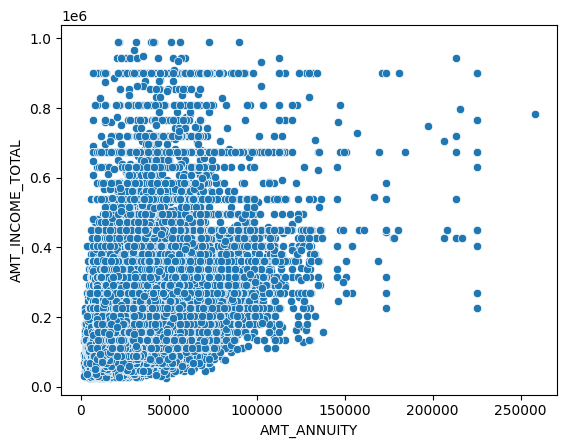

In [7]:
df_filtrado = dataset[dataset['AMT_INCOME_TOTAL'] < 1000000].copy() # Eliminando Outliers
sns.scatterplot(data=df_filtrado, x='AMT_ANNUITY', y='AMT_INCOME_TOTAL')

In [8]:
def parcela_salario(parcela: float, salario: float):
    
    ps = (parcela / salario) * 100 
    
    return ps

In [17]:
df_renda_parcela = pd.DataFrame({
    'renda':df_filtrado['AMT_INCOME_TOTAL'],
    'valor_parcela':dataset['AMT_ANNUITY'],
    'porcentagem_parcela_salario': parcela_salario(dataset['AMT_ANNUITY'], df_filtrado['AMT_INCOME_TOTAL']),
    
})

<Axes: >

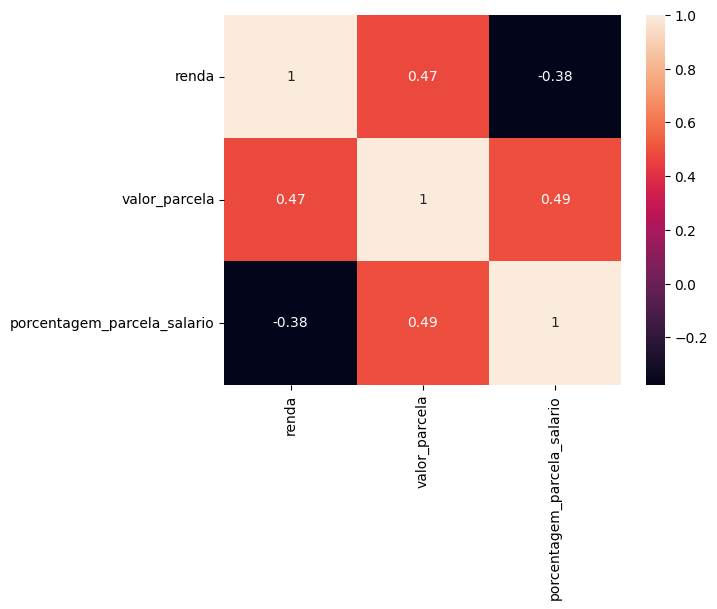

In [18]:
sns.heatmap(df_renda_parcela.corr(), annot=True)

<Axes: xlabel='salario', ylabel='valor_parcela'>

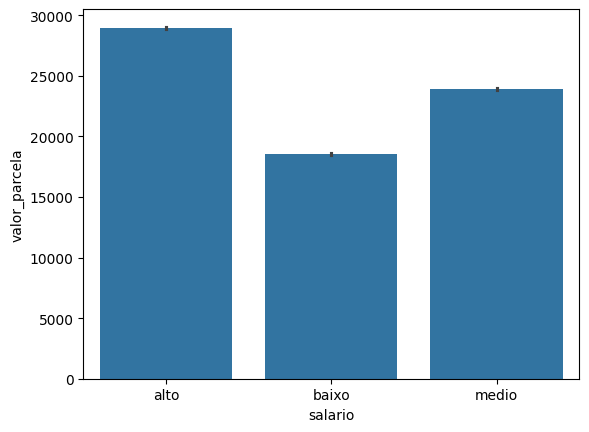

In [11]:
sns.barplot(data=salario_target, x='salario', y='valor_parcela')

<Axes: xlabel='salario', ylabel='porcentagem_parcela_salario'>

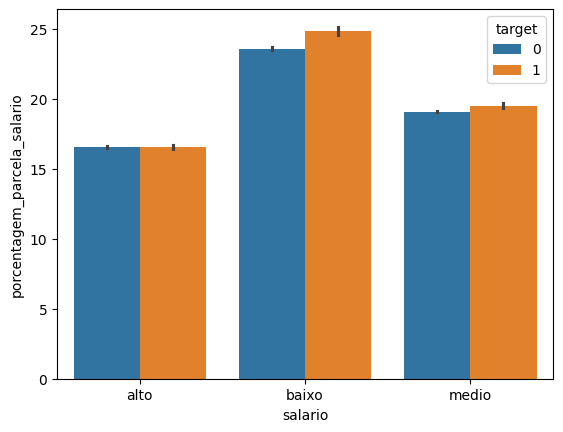

In [12]:
sns.barplot(x=salario_target['salario'], y=df_renda_parcela['porcentagem_parcela_salario'], hue=salario_target['target'])

Conclusões:

- Muito raro alguém com renda baixa pagando uma parcela altíssima (percebido pelo vazio do canto inferior direito)

- A maior densidade dos dados está em clientes com renda até 300k e parcelas até 50k, ou seja, os maiores clientes dos bancos são pessoas de classe média/baixa

- A renda e as parcelas apresentam uma relação diretamente proporcional (confirmada pela correlação moderada de 0.47), mas é possível identificar que pessoas pessoas com mesma renda pagam valores diferentes de parcelas

- Pessoas com salário baixa comprometem uma fatia maior da sua renda com a parcela (chegando a 25%), enquanto pessoas com salário baixo comprometem 17%

- Maior taxa de inadimplentes são pessoas que possuem salário baixo com alta porcentagem de comprometimento

- Porcentagem da parcela em salários altos não é preditivo se o cliente pagará ou não, pois, apresentando a mesma porcentagem, teve que pessoas que pegaram e outras não

#### Quem pede crédito acima do valor do bem inadimpla mais?

In [ ]:
def lucro_cliente_empretimo(credito: float, valor_bem: float):
    
    le = credito - valor_bem
    
    return le

In [28]:
def pegou_oq_precisava(lucro_cliente_empretimo: float):
    if lucro_cliente_empretimo > 0:
        return 'Pegou mais'
    elif lucro_cliente_empretimo == 0:
        return 'Pegou Oq precisava'
    else:
        return 'Pegou menos'

In [29]:
df_renda_parcela = pd.DataFrame({
    'renda':df_filtrado['AMT_INCOME_TOTAL'],
    'valor_parcela':dataset['AMT_ANNUITY'],
    'porcentagem_parcela_salario': parcela_salario(dataset['AMT_ANNUITY'], df_filtrado['AMT_INCOME_TOTAL']),
    'lucro_cliente_emprestimo':lucro_cliente_empretimo(dataset['AMT_CREDIT'], dataset['AMT_GOODS_PRICE']),
    'pegou_oq_precisava': df_renda_parcela['lucro_cliente_emprestimo'].apply(pegou_oq_precisava),
    'target':dataset['TARGET']
})


In [30]:
df_renda_parcela

,renda,valor_parcela,porcentagem_parcela_salario,lucro_cliente_emprestimo,pegou_oq_precisava,target
0,202500.0,24700.5,12.197778,55597.5,Pegou mais,1
1,270000.0,35698.5,13.221667,164002.5,Pegou mais,0
2,67500.0,6750.0,10.000000,0.0,Pegou Oq precisava,0
3,135000.0,29686.5,21.990000,15682.5,Pegou mais,0
4,121500.0,21865.5,17.996296,0.0,Pegou Oq precisava,0
...,...,...,...,...,...,...
307506,157500.0,27558.0,17.497143,29700.0,Pegou mais,0
307507,72000.0,12001.5,16.668750,44550.0,Pegou mais,0
307508,153000.0,29979.0,19.594118,92664.0,Pegou mais,0
307509,171000.0,20205.0,11.815789,50607.0,Pegou mais,1


<Axes: xlabel='pegou_oq_precisava', ylabel='count'>

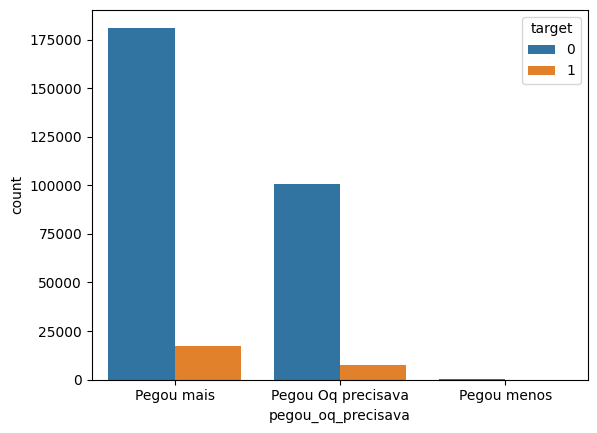

In [32]:
sns.countplot(data=df_renda_parcela, x='pegou_oq_precisava', hue='target')

Quantidade de inadimplentes

In [34]:
df_renda_parcela.loc[df_renda_parcela['target'] == 1].shape[0]

24825

In [37]:
df_renda_parcela.loc[(df_renda_parcela['pegou_oq_precisava'] == 'Pegou mais') & (df_renda_parcela['target'] == 1)].shape[0]

17486

In [39]:
df_renda_parcela.loc[(df_renda_parcela['pegou_oq_precisava'] == 'Pegou Oq precisava') & (df_renda_parcela['target'] == 1)].shape[0]

7305

In [41]:
df_renda_parcela.loc[(df_renda_parcela['pegou_oq_precisava'] == 'Pegou menos') & (df_renda_parcela['target'] == 1)].shape[0]

34

70,43% dos inadimplentes pegaram mais do que precisavam

In [38]:
(17486 / 24825) * 100

70.43705941591139

29,42% dos inadimplentes pegaram o que precisavam

In [40]:
(7305 / 24825) * 100

29.425981873111784

0,13% dos inadimplentes pegaram menos do que deveria

In [42]:
(34 / 24825) * 100

0.13695871097683787

Probabilidade de inadimplência por grupo

In [43]:
df_renda_parcela.loc[df_renda_parcela['pegou_oq_precisava'] == 'Pegou mais'].shape[0]

198763

In [45]:
df_renda_parcela.loc[df_renda_parcela['pegou_oq_precisava'] == 'Pegou Oq precisava'].shape[0]

108210

In [46]:
df_renda_parcela.loc[df_renda_parcela['pegou_oq_precisava'] == 'Pegou menos'].shape[0]

538

8,79% das pessoas que pegaram mais entraram em inadimplencia

In [47]:
(17486 / 198763) * 100

8.797411993177805

6,75% das pessoas que pegaram o que precisavam entraram em inadimplencia

In [48]:
(7305 / 108210) * 100

6.750762406431939

6,31% das pessoas que pegaram menos entraram em inadimplência

In [50]:
(34 / 538) * 100

6.319702602230483

Conclusão:

- Uma pessoa que pegou um crédito maior que o valor do bem, tem 40% mais probabilidade de entrar em inadimplência que uma pessoa que pegou menos

#### O risco diminui com a idade?

In [53]:
dataset['DAYS_BIRTH'].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

In [57]:
df_renda_parcela = pd.DataFrame({
    'renda':df_filtrado['AMT_INCOME_TOTAL'],
    'valor_parcela':dataset['AMT_ANNUITY'],
    'porcentagem_parcela_salario': parcela_salario(dataset['AMT_ANNUITY'], df_filtrado['AMT_INCOME_TOTAL']),
    'lucro_cliente_emprestimo':lucro_cliente_empretimo(dataset['AMT_CREDIT'], dataset['AMT_GOODS_PRICE']),
    'pegou_oq_precisava': df_renda_parcela['lucro_cliente_emprestimo'].apply(pegou_oq_precisava),
    'idade_anos': (dataset['DAYS_BIRTH'] / -365).astype(int),
    'target':dataset['TARGET']
    
})


In [58]:
df_renda_parcela

,renda,valor_parcela,porcentagem_parcela_salario,lucro_cliente_emprestimo,pegou_oq_precisava,idade_anos,target
0,202500.0,24700.5,12.197778,55597.5,Pegou mais,25,1
1,270000.0,35698.5,13.221667,164002.5,Pegou mais,45,0
2,67500.0,6750.0,10.000000,0.0,Pegou Oq precisava,52,0
3,135000.0,29686.5,21.990000,15682.5,Pegou mais,52,0
4,121500.0,21865.5,17.996296,0.0,Pegou Oq precisava,54,0
...,...,...,...,...,...,...,...
307506,157500.0,27558.0,17.497143,29700.0,Pegou mais,25,0
307507,72000.0,12001.5,16.668750,44550.0,Pegou mais,56,0
307508,153000.0,29979.0,19.594118,92664.0,Pegou mais,41,0
307509,171000.0,20205.0,11.815789,50607.0,Pegou mais,32,1


<Axes: xlabel='idade_anos', ylabel='porcentagem_parcela_salario'>

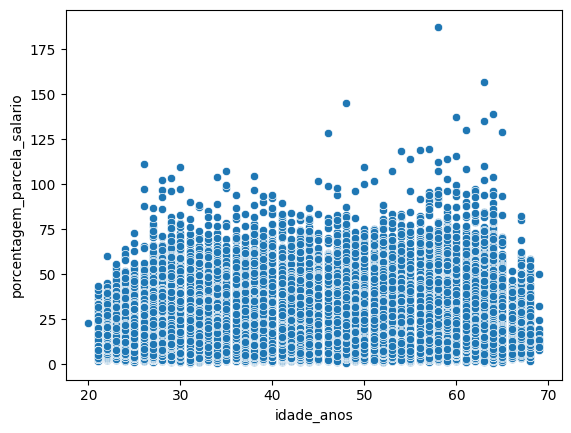

In [60]:
sns.scatterplot(data=df_renda_parcela, x='idade_anos', y='porcentagem_parcela_salario')

In [61]:
df_renda_parcela['idade_anos'].describe()

count    307511.000000
mean         43.435968
std          11.954593
min          20.000000
25%          34.000000
50%          43.000000
75%          53.000000
max          69.000000
Name: idade_anos, dtype: float64

In [62]:
bins = [20, 30, 40, 50, 60, 70]
labels = ['20-30', '30-40', '40-50', '50-60', '60-70']

df_renda_parcela['faixa_etaria'] = pd.cut(df_renda_parcela['idade_anos'], bins=bins, labels=labels, right=False)

<Axes: xlabel='faixa_etaria', ylabel='target'>

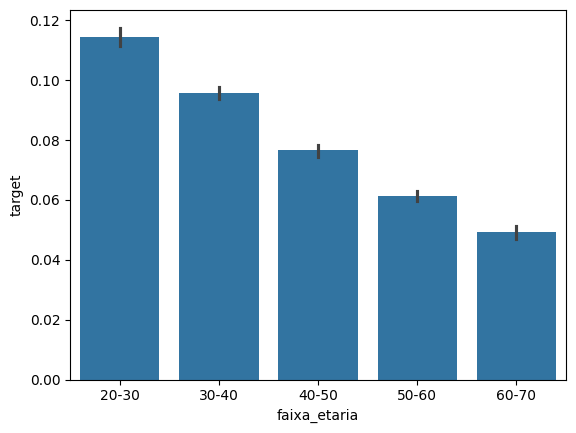

In [63]:
sns.barplot(data=df_renda_parcela, x='faixa_etaria', y='target')

In [69]:
# Criando uma tabela com a taxa de inadimplência por faixa
taxas_por_idade = df_renda_parcela.groupby('faixa_etaria')['target'].mean()

# Pegando os valores específicos dos extremos
taxa_jovens = taxas_por_idade['20-30']
taxa_m = taxas_por_idade['30-40']
taxa_mm = taxas_por_idade['40-50']
taxa_mmm = taxas_por_idade['50-60']
taxa_idosos = taxas_por_idade['60-70']

# Calculando a diferença percentual
risco_a_mais_jovem_adulto = (taxa_jovens / taxa_idosos - 1) * 100
risco_a_mais_adulto = (taxa_m / taxa_idosos - 1) * 100
risco_a_mais_adulto_velho = (taxa_mm / taxa_idosos - 1) * 100
risco_a_mais_adulto_mais_velho = (taxa_mmm / taxa_idosos - 1) * 100

print(f"Um 20-30 tem {risco_a_mais_jovem_adulto:.2f}% a mais de chance de inadimplir que um idoso.")
print(f"Um 30-40 tem {risco_a_mais_adulto:.2f}% a mais de chance de inadimplir que um idoso.")
print(f"Um 40-50 tem {risco_a_mais_adulto_velho:.2f}% a mais de chance de inadimplir que um idoso.")
print(f"Um 50-60 tem {risco_a_mais_adulto_mais_velho:.2f}% a mais de chance de inadimplir que um idoso.")




Um 20-30 tem 132.74% a mais de chance de inadimplir que um idoso.
Um 30-40 tem 94.65% a mais de chance de inadimplir que um idoso.
Um 40-50 tem 55.54% a mais de chance de inadimplir que um idoso.
Um 50-60 tem 24.54% a mais de chance de inadimplir que um idoso.


C:\Users\pgssd\AppData\Local\Temp\ipykernel_11592\289103539.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxas_por_idade = df_renda_parcela.groupby('faixa_etaria')['target'].mean()


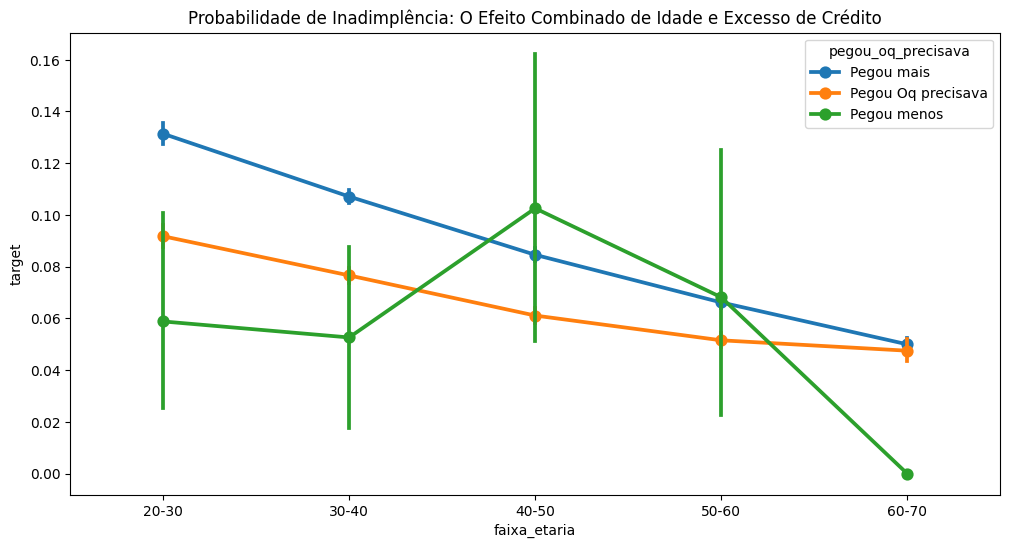

In [ ]:
plt.figure(figsize=(12,6))
sns.pointplot(data=df_renda_parcela, x='faixa_etaria', y='target', hue='pegou_oq_precisava')
plt.title('Probabilidade de Inadimplência: O Efeito Combinado de Idade e Excesso de Crédito')
plt.show()

Conclusões:
- Um 20-30 tem 132.74% a mais de chance de inadimplir que um idoso.
- Um 30-40 tem 94.65% a mais de chance de inadimplir que um idoso.
- Um 40-50 tem 55.54% a mais de chance de inadimplir que um idoso.
- Um 50-60 tem 24.54% a mais de chance de inadimplir que um idoso.